# Examen Enero 2025 — HeartDisease (heart.csv) — Guía paso a paso (práctica + teoría)

**Nombre:** _TU NOMBRE AQUÍ_

Este notebook sigue el enunciado del examen (enero 2025) y está pensado para que lo puedas **imitar en el examen**:  
- cada ejercicio está separado,
- hay **markdown explicando decisiones**,
- y el preprocesado está hecho de forma **reutilizable** (pipeline).

> Dataset: `heart.csv` (incluido con el enunciado).  
> Split obligatorio: `test_size=0.25`, `random_state=0`.  


## 0) Imports y carga

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", 200)


In [2]:
DATA_PATH = "data/heart.csv"
df_raw = pd.read_csv(DATA_PATH)

print("Shape:", df_raw.shape)
df_raw.head()


Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172.0,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156.0,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98.0,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108.0,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122.0,N,0.0,Up,0


### Inspección rápida (tip de examen: siempre mira tipos y NaNs)

In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             917 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      917 non-null    object 
 7   MaxHR           917 non-null    float64
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 86.2+ KB


In [4]:
# NaNs por columna
df_raw.isna().sum()


Age               0
Sex               1
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        1
MaxHR             1
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## Ejercicio 1 (0.5): Limpieza + transformaciones (justificadas)

El enunciado pide “limpia el dataset y realiza las transformaciones necesarias para que sea aplicable a cualquier modelo”.

### 1) Qué suele “contar” en examen (y por qué)
- **Detectar valores faltantes** (`NaN`) y tratarlos (imputación o eliminación justificada).
- **Detectar valores “imposibles”** (por ejemplo colesterol=0) y tratarlos como faltantes si es razonable.
- **Codificar categóricas**: `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`.
- (Opcional pero recomendable) **Estandarizar numéricas** cuando uses modelos sensibles a escala (MLP, KNN).

### 2) Decisiones de limpieza que hacemos aquí
- Hay algunos `NaN` en `Sex`, `RestingECG`, `MaxHR`. Los imputamos con:
  - **most_frequent** para categóricas,
  - **mediana** para numéricas.
- Tratamos `Cholesterol == 0` como *valor inválido* (0 mm/dl es irrealista) y lo convertimos a `NaN` para imputarlo.
- Tratamos `RestingBP == 0` como inválido (0 mm Hg no tiene sentido).

> Estas decisiones suelen puntuar bien porque NO borras filas “a lo loco” y mantienes el dataset estable.


In [5]:
df = df_raw.copy()

# Convertimos valores imposibles a NaN para imputación posterior
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)
df["RestingBP"]   = df["RestingBP"].replace(0, np.nan)

# Separación X/y
X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"].astype(int)

# Columnas
cat_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
num_cols = [c for c in X.columns if c not in cat_cols]

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)


Numéricas: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categóricas: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


### Pipeline de preprocesado (reutilizable)

La idea (muy “de examen”) es: **un único pipeline** que te sirve para MLP, KNN, etc.  
- Numéricas: imputación mediana + **StandardScaler**  
- Categóricas: imputación moda + **OneHotEncoder**

Nota: ponemos `sparse_output=False` para que salga una matriz densa (más fácil de usar con NumPy y suele ir rápido con este dataset).


In [6]:
preprocess_dense = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cat_cols),
    ],
    remainder="drop"
)

# Split obligatorio del enunciado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Distribución y (train):\n", y_train.value_counts(normalize=True))
print("Distribución y (test):\n", y_test.value_counts(normalize=True))


Train: (688, 11) Test: (230, 11)
Distribución y (train):
 HeartDisease
1    0.553779
0    0.446221
Name: proportion, dtype: float64
Distribución y (test):
 HeartDisease
1    0.552174
0    0.447826
Name: proportion, dtype: float64


## Ejercicio 2 (0.5): Representación de distribución de clases

Normalmente basta con un bar plot con el recuento de:
- `HeartDisease=0` (normal)
- `HeartDisease=1` (cardiopatía)


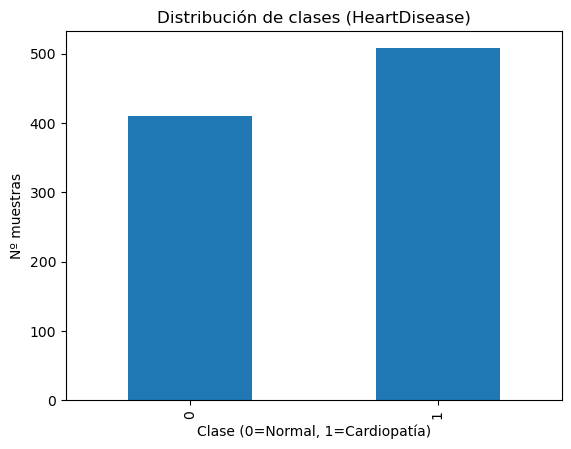

In [7]:
plt.figure()
y.value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de clases (HeartDisease)")
plt.xlabel("Clase (0=Normal, 1=Cardiopatía)")
plt.ylabel("Nº muestras")
plt.show()


## Ejercicio 3 (2.0): MLP propio (NumPy) — accuracy >= 84%

El examen pide usar vuestro MLP de prácticas 5/6 y **hacer al menos una prueba con >1 capa oculta**.

Aquí implementamos un MLP binario simple:
- Capas ocultas: ReLU
- Capa de salida: **sigmoid** (logistic)
- Loss: **binary cross-entropy** (BCE)
- Entrenamiento: mini-batch gradient descent

> Consejo de examen: separa (a) preprocesado, (b) definición del modelo, (c) entrenamiento, (d) evaluación.


In [8]:
# Pasamos a NumPy con el mismo preprocesado (para usar el MLP propio)
X_train_t = preprocess_dense.fit_transform(X_train)
X_test_t  = preprocess_dense.transform(X_test)

y_train_np = y_train.to_numpy()
y_test_np  = y_test.to_numpy()

print("X_train_t:", X_train_t.shape, "X_test_t:", X_test_t.shape)


X_train_t: (688, 20) X_test_t: (230, 20)


In [9]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

class NumpyMLPBinary:
    """MLP binario con múltiples capas ocultas y salida logistic (sigmoid)."""
    def __init__(self, layer_sizes, seed=0, l2=1e-5, hidden_activation="relu"):
        # layer_sizes: [n_in, h1, h2, ..., 1]
        self.sizes = list(layer_sizes)
        self.rng = np.random.default_rng(seed)
        self.l2 = float(l2)
        self.hidden_activation = hidden_activation

        self.W = []
        self.b = []
        for i in range(len(self.sizes) - 1):
            fan_in = self.sizes[i]
            fan_out = self.sizes[i + 1]

            # He init para ReLU en capas ocultas
            if i < len(self.sizes) - 2 and hidden_activation == "relu":
                scale = np.sqrt(2.0 / fan_in)
            else:
                scale = np.sqrt(1.0 / fan_in)

            self.W.append(self.rng.normal(0, scale, size=(fan_in, fan_out)).astype(np.float32))
            self.b.append(np.zeros((1, fan_out), dtype=np.float32))

    def _act(self, z):
        if self.hidden_activation == "relu":
            return np.maximum(0, z)
        if self.hidden_activation == "tanh":
            return np.tanh(z)
        raise ValueError("hidden_activation no soportada")

    def _act_deriv(self, z, a):
        if self.hidden_activation == "relu":
            return (z > 0).astype(np.float32)
        if self.hidden_activation == "tanh":
            return 1.0 - a * a
        raise ValueError("hidden_activation no soportada")

    def forward(self, X):
        a = X.astype(np.float32)
        activations = [a]
        zs = []
        for i in range(len(self.W)):
            z = a @ self.W[i] + self.b[i]
            zs.append(z)
            if i == len(self.W) - 1:
                a = sigmoid(z)           # salida logistic
            else:
                a = self._act(z)         # ocultas
            activations.append(a)
        return activations, zs

    def predict_proba(self, X):
        a = X.astype(np.float32)
        for i in range(len(self.W)):
            z = a @ self.W[i] + self.b[i]
            if i == len(self.W) - 1:
                a = sigmoid(z)
            else:
                a = self._act(z)
        return a.ravel()

    def predict(self, X, thresh=0.5):
        return (self.predict_proba(X) >= thresh).astype(int)

    def fit(self, X, y, epochs=2000, lr=0.01, batch_size=32, verbose_every=0):
        X = X.astype(np.float32)
        y = y.astype(np.float32).reshape(-1, 1)
        n = X.shape[0]

        for ep in range(epochs):
            idx = self.rng.permutation(n)
            Xs = X[idx]
            ys = y[idx]

            for start in range(0, n, batch_size):
                xb = Xs[start:start+batch_size]
                yb = ys[start:start+batch_size]

                activations, zs = self.forward(xb)
                out = activations[-1]

                # BCE + sigmoid => delta = (out - y)
                delta = (out - yb) / xb.shape[0]

                dW = [None] * len(self.W)
                db = [None] * len(self.b)

                for i in reversed(range(len(self.W))):
                    a_prev = activations[i]
                    dW[i] = a_prev.T @ delta + self.l2 * self.W[i]
                    db[i] = np.sum(delta, axis=0, keepdims=True)

                    if i > 0:
                        delta = (delta @ self.W[i].T) * self._act_deriv(zs[i-1], activations[i])

                for i in range(len(self.W)):
                    self.W[i] -= lr * dW[i]
                    self.b[i] -= lr * db[i]

            if verbose_every and (ep % verbose_every == 0 or ep == epochs - 1):
                acc = (self.predict(X) == y.ravel()).mean()
                print(f"Epoch {ep:4d} | train acc = {acc:.3f}")

        return self


### (Obligatorio) Prueba con 1 sola capa oculta (baseline)

No tiene por qué ser tu modelo final; sirve para comparar.


Accuracy MLP propio (1 hidden): 0.8565217391304348


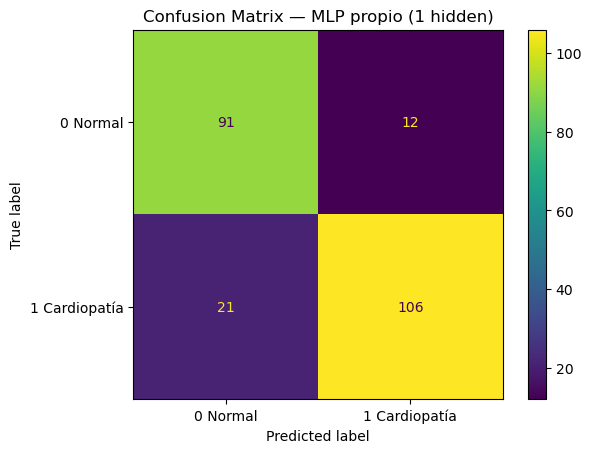

In [10]:
# 1 capa oculta (prueba)
mlp_1h = NumpyMLPBinary(
    layer_sizes=[X_train_t.shape[1], 32, 1],
    seed=0, l2=1e-5, hidden_activation="relu"
)
mlp_1h.fit(X_train_t, y_train_np, epochs=1500, lr=0.01, batch_size=32)

pred_1h = mlp_1h.predict(X_test_t)
acc_1h = accuracy_score(y_test_np, pred_1h)
print("Accuracy MLP propio (1 hidden):", acc_1h)

cm = confusion_matrix(y_test_np, pred_1h, labels=[0,1])
disp = ConfusionMatrixDisplay(cm, display_labels=["0 Normal", "1 Cardiopatía"])
disp.plot(values_format="d")
plt.title("Confusion Matrix — MLP propio (1 hidden)")
plt.show()


### Prueba con >1 capa oculta (requisito del examen)

Aquí usamos 2 capas ocultas (128, 64).  
Este modelo suele superar el 84% en este dataset con este split.


Accuracy MLP propio (2 hidden): 0.8478260869565217


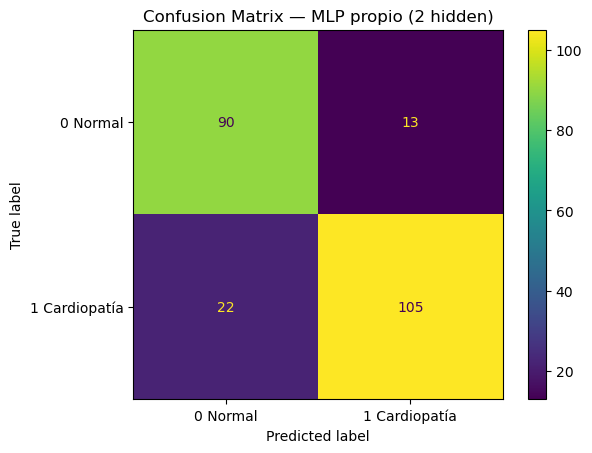

MODELO FINAL (MLP propio): 1 hidden


In [11]:
mlp_2h = NumpyMLPBinary(
    layer_sizes=[X_train_t.shape[1], 128, 64, 1],
    seed=0, l2=1e-5, hidden_activation="relu"
)
mlp_2h.fit(X_train_t, y_train_np, epochs=2000, lr=0.01, batch_size=32)

pred_2h = mlp_2h.predict(X_test_t)
acc_2h = accuracy_score(y_test_np, pred_2h)
print("Accuracy MLP propio (2 hidden):", acc_2h)

cm = confusion_matrix(y_test_np, pred_2h, labels=[0,1])
disp = ConfusionMatrixDisplay(cm, display_labels=["0 Normal", "1 Cardiopatía"])
disp.plot(values_format="d")
plt.title("Confusion Matrix — MLP propio (2 hidden)")
plt.show()

print("MODELO FINAL (MLP propio):", "2 hidden" if acc_2h >= acc_1h else "1 hidden")


## Ejercicio 4 (1.0): MLPClassifier (sklearn) — accuracy >= 84%

Aquí podemos ajustar hiperparámetros libremente.
Con este dataset funciona bien usar:
- OneHot dense + StandardScaler (ya lo tenemos)
- `hidden_layer_sizes=(128,64)`
- `early_stopping=True` para evitar sobreajuste


Accuracy MLPClassifier: 0.8782608695652174
              precision    recall  f1-score   support

           0      0.857     0.874     0.865       103
           1      0.896     0.882     0.889       127

    accuracy                          0.878       230
   macro avg      0.877     0.878     0.877       230
weighted avg      0.879     0.878     0.878       230



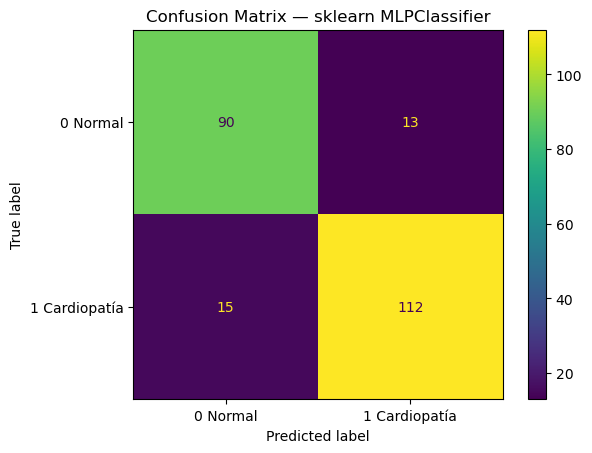

In [12]:
sk_mlp = Pipeline(steps=[
    ("pre", preprocess_dense),
    ("model", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=2000,
        early_stopping=True,
        random_state=0
    ))
])

sk_mlp.fit(X_train, y_train)
pred = sk_mlp.predict(X_test)

acc = accuracy_score(y_test, pred)
print("Accuracy MLPClassifier:", acc)
print(classification_report(y_test, pred, digits=3))

cm = confusion_matrix(y_test, pred, labels=[0,1])
disp = ConfusionMatrixDisplay(cm, display_labels=["0 Normal", "1 Cardiopatía"])
disp.plot(values_format="d")
plt.title("Confusion Matrix — sklearn MLPClassifier")
plt.show()


## Ejercicio 5 (1.0): KNN — accuracy >= 84%

KNN es muy sensible a escala → usamos el mismo `preprocess_dense` (StandardScaler + one-hot).
Probamos varios `k` y nos quedamos con uno que cumpla el 84%.


In [13]:
best = (0, None)
for k in [3,5,7,9,11,15]:
    knn = Pipeline(steps=[
        ("pre", preprocess_dense),
        ("model", KNeighborsClassifier(n_neighbors=k, weights="distance"))
    ])
    knn.fit(X_train, y_train)
    acc_k = accuracy_score(y_test, knn.predict(X_test))
    print("k =", k, "acc =", acc_k)
    if acc_k > best[0]:
        best = (acc_k, k)

print("Mejor k:", best[1], "con acc:", best[0])


k = 3 acc = 0.8434782608695652
k = 5 acc = 0.8652173913043478
k = 7 acc = 0.8739130434782608
k = 9 acc = 0.8739130434782608
k = 11 acc = 0.8739130434782608
k = 15 acc = 0.8782608695652174
Mejor k: 15 con acc: 0.8782608695652174


Accuracy KNN final: 0.8782608695652174
              precision    recall  f1-score   support

           0      0.864     0.864     0.864       103
           1      0.890     0.890     0.890       127

    accuracy                          0.878       230
   macro avg      0.877     0.877     0.877       230
weighted avg      0.878     0.878     0.878       230



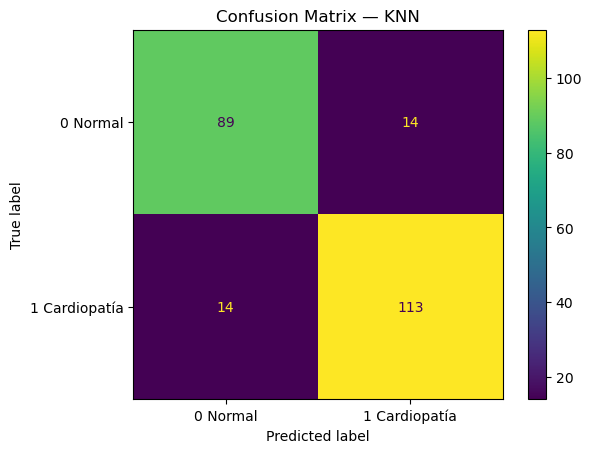

In [14]:
k_final = best[1] if best[1] is not None else 15

knn_final = Pipeline(steps=[
    ("pre", preprocess_dense),
    ("model", KNeighborsClassifier(n_neighbors=k_final, weights="distance"))
])
knn_final.fit(X_train, y_train)
pred = knn_final.predict(X_test)

acc = accuracy_score(y_test, pred)
print("Accuracy KNN final:", acc)
print(classification_report(y_test, pred, digits=3))

cm = confusion_matrix(y_test, pred, labels=[0,1])
disp = ConfusionMatrixDisplay(cm, display_labels=["0 Normal", "1 Cardiopatía"])
disp.plot(values_format="d")
plt.title("Confusion Matrix — KNN")
plt.show()


## Ejercicio 6 (1.0): RandomForestClassifier — accuracy >= 84%

RandomForest no necesita escalado, pero sí:
- imputación,
- one-hot para categóricas.

Aquí usamos un pipeline separado (sin scaler).


Accuracy RandomForest: 0.8869565217391304
              precision    recall  f1-score   support

           0      0.867     0.883     0.875       103
           1      0.904     0.890     0.897       127

    accuracy                          0.887       230
   macro avg      0.885     0.887     0.886       230
weighted avg      0.887     0.887     0.887       230



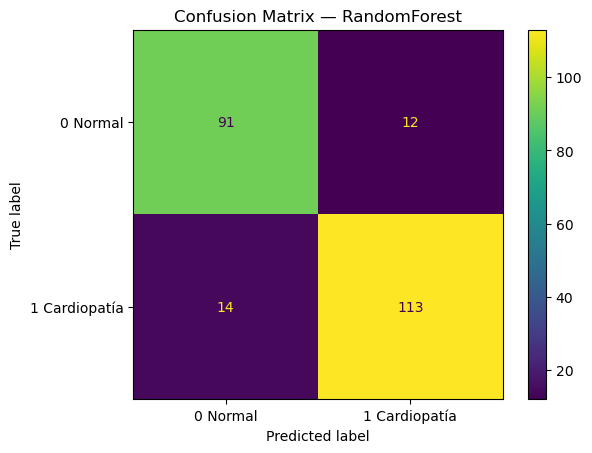

In [15]:
preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ],
    remainder="drop"
)

rf = Pipeline(steps=[
    ("pre", preprocess_rf),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=0
    ))
])

rf.fit(X_train, y_train)
pred = rf.predict(X_test)

acc = accuracy_score(y_test, pred)
print("Accuracy RandomForest:", acc)
print(classification_report(y_test, pred, digits=3))

cm = confusion_matrix(y_test, pred, labels=[0,1])
disp = ConfusionMatrixDisplay(cm, display_labels=["0 Normal", "1 Cardiopatía"])
disp.plot(values_format="d")
plt.title("Confusion Matrix — RandomForest")
plt.show()


## Ejercicio (comparación final): ¿Con qué modelo me quedo?

El examen pide justificar el modelo final con matrices de confusión y métricas.

En un contexto médico suele ser importante mirar:
- **Recall de la clase 1 (cardiopatía)**: cuántos enfermos detecto.
- **Falsos negativos** (FN): enfermos que el modelo marca como sanos (peligroso).
- Además del accuracy.

Aquí comparamos los 4 modelos:  
- MLP propio (1 hidden y 2 hidden)  
- sklearn MLPClassifier  
- KNN  
- RandomForest


In [16]:
def eval_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    recall_pos = tp / (tp + fn + 1e-9)
    precision_pos = tp / (tp + fp + 1e-9)
    return {
        "model": name,
        "accuracy": acc,
        "precision_class1": precision_pos,
        "recall_class1": recall_pos,
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "TN": int(tn),
    }

results = []
results.append(eval_model("MLP propio (1 hidden)", y_test_np, pred_1h))
results.append(eval_model("MLP propio (2 hidden)", y_test_np, pred_2h))
results.append(eval_model("sklearn MLPClassifier", y_test.to_numpy(), sk_mlp.predict(X_test)))
results.append(eval_model(f"KNN (k={k_final})", y_test.to_numpy(), knn_final.predict(X_test)))
results.append(eval_model("RandomForest", y_test.to_numpy(), rf.predict(X_test)))

res_df = pd.DataFrame(results).sort_values(["accuracy", "recall_class1"], ascending=False)
res_df


,model,accuracy,precision_class1,recall_class1,FP,FN,TP,TN
4,RandomForest,0.886957,0.904000,0.889764,12,14,113,91
3,KNN (k=15),0.878261,0.889764,0.889764,14,14,113,89
2,sklearn MLPClassifier,0.878261,0.896000,0.881890,13,15,112,90
0,MLP propio (1 hidden),0.856522,0.898305,0.834646,12,21,106,91
1,MLP propio (2 hidden),0.847826,0.889831,0.826772,13,22,105,90


### Justificación (ejemplo de texto)

- Si el objetivo principal es **maximizar accuracy**, probablemente gane RandomForest o KNN.
- Si el objetivo es minimizar **falsos negativos** (no dejar enfermos sin detectar), me fijo sobre todo en `FN` y en el `recall` de la clase 1.

Copia/pega y ajusta con tus valores:
> Me quedo con ____ porque obtiene la mejor combinación de accuracy y recall para la clase de cardiopatía.  
> En concreto, reduce los falsos negativos, lo cual es crítico en un problema médico donde es peor “no detectar” que “dar un falso aviso”.


## Ejercicio 6 (1.0): Opción de salida 'logistic' o 'softmax' en el MLP propio

El enunciado pide poder pasar al constructor un parámetro `output="logistic"` o `output="softmax"`.

**Interpretación práctica (lo típico):**
- `logistic`: salida sigmoid (útil para binario o one-vs-all)
- `softmax`: salida softmax (multi-clase con clases mutuamente excluyentes)

Abajo tienes una versión mínima que añade softmax en la **capa de salida**.
(En binario es más común logistic; softmax sirve si haces 2 neuronas de salida.)


In [17]:
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp = np.exp(z)
    return exp / np.sum(exp, axis=1, keepdims=True)

class NumpyMLPOutputChoice:
    """MLP simple con salida configurable: logistic (sigmoid) o softmax."""
    def __init__(self, layer_sizes, output="logistic", seed=0):
        self.sizes = list(layer_sizes)
        self.output = output
        self.rng = np.random.default_rng(seed)

        self.W = []
        self.b = []
        for i in range(len(self.sizes) - 1):
            fan_in = self.sizes[i]
            fan_out = self.sizes[i + 1]
            scale = np.sqrt(2.0 / fan_in) if i < len(self.sizes) - 2 else np.sqrt(1.0 / fan_in)
            self.W.append(self.rng.normal(0, scale, size=(fan_in, fan_out)).astype(np.float32))
            self.b.append(np.zeros((1, fan_out), dtype=np.float32))

    def forward(self, X):
        a = X.astype(np.float32)
        activations = [a]
        zs = []
        for i in range(len(self.W)):
            z = a @ self.W[i] + self.b[i]
            zs.append(z)
            if i == len(self.W) - 1:
                if self.output == "softmax":
                    a = softmax(z)
                else:
                    a = sigmoid(z)
            else:
                a = np.maximum(0, z)  # ReLU
            activations.append(a)
        return activations, zs

    def predict(self, X):
        out = self.forward(X)[0][-1]
        if self.output == "softmax":
            return np.argmax(out, axis=1)
        else:
            # si logistic con 1 neurona
            if out.shape[1] == 1:
                return (out.ravel() >= 0.5).astype(int)
            # logistic con varias neuronas (one-vs-all)
            return np.argmax(out, axis=1)

# DEMO softmax con 2 salidas (clases 0/1 en one-hot)
Y_train_oh = np.eye(2)[y_train_np]
Y_test_oh  = np.eye(2)[y_test_np]

mlp_soft = NumpyMLPOutputChoice([X_train_t.shape[1], 64, 2], output="softmax", seed=0)

# Entrenamiento rápido solo como demo (NO optimizado)
lr = 0.05
epochs = 400
batch_size = 32

for ep in range(epochs):
    idx = np.random.permutation(X_train_t.shape[0])
    Xs = X_train_t[idx]
    Ys = Y_train_oh[idx]
    for s in range(0, Xs.shape[0], batch_size):
        xb = Xs[s:s+batch_size]
        yb = Ys[s:s+batch_size]
        activ, zs = mlp_soft.forward(xb)
        out = activ[-1]
        delta = (out - yb) / xb.shape[0]  # softmax + CE

        # backprop (1 hidden)
        dW2 = activ[1].T @ delta
        db2 = np.sum(delta, axis=0, keepdims=True)
        delta1 = (delta @ mlp_soft.W[1].T) * (zs[0] > 0).astype(np.float32)
        dW1 = activ[0].T @ delta1
        db1 = np.sum(delta1, axis=0, keepdims=True)

        mlp_soft.W[1] -= lr * dW2
        mlp_soft.b[1] -= lr * db2
        mlp_soft.W[0] -= lr * dW1
        mlp_soft.b[0] -= lr * db1

pred_demo = mlp_soft.predict(X_test_t)
print("DEMO softmax acc:", accuracy_score(y_test_np, pred_demo))


DEMO softmax acc: 0.8434782608695652


--- 
## Fin

Este notebook está hecho para que puedas **copiar la receta** en examen:
1) limpieza → 2) pipeline → 3) split fijo → 4) entrenar modelos → 5) matrices de confusión + justificación.

Siguiente paso recomendado:
- si quieres, te preparo una “chuleta de limpieza” de 10 líneas (solo decisiones típicas y cómo justificarlas).
